<div style='background:#0d1117;padding:30px 24px;border-radius:10px;text-align:center;border-left:6px solid #4CAF50'>
  <h1 style='color:#ffffff;margin:0;font-size:2em;letter-spacing:1px'>Week 9 — Area Charts</h1>
  <p style='color:#a5d6a7;font-size:1.1em;margin:10px 0 4px 0'>Visualizing Volume Over Time</p>
</div>

## Learning Objectives

By the end of this session you will be able to:

- Explain what an **area chart** is and how it extends a line chart
- Understand why **area charts require the y-axis to start at zero**
- Distinguish between **line charts vs area charts**
- Understand when filling the area adds value — and when it misleads
- Build area charts using **Matplotlib**, **Seaborn**, and **Plotly**
- Understand **stacked area charts** and when to use them
- Avoid common mistakes (wrong baseline, too many categories, misleading comparisons)

## Part 1 — From Line Chart to Area Chart

In Week 8, we saw four representations:

1. Dots  
2. Dots + Lines  
3. Lines only  
4. **Filled Area (today’s focus)**  

<div style="display:grid; grid-template-columns:1fr 1fr; gap:16px; background:#0d1117; padding:20px; border-radius:10px; margin-bottom:16px;">
  <div style="text-align:center;">
    <p style="color:#a5d6a7; font-weight:bold; margin-bottom:6px;">Step 1 — Dots only</p>
    <img src="images/fig13_1.png" style="width:100%; height:400px; object-fit:cover; border-radius:6px;">
    <p style="color:#888; font-size:0.85em; margin-top:6px;">Individual observations — trend harder to follow</p>
  </div>
  <div style="text-align:center;">
    <p style="color:#a5d6a7; font-weight:bold; margin-bottom:6px;">Step 2 — Dots + Lines</p>
    <img src="images/fig13_2.png" style="width:100%; height:400px; object-fit:cover; border-radius:6px;">
    <p style="color:#888; font-size:0.85em; margin-top:6px;">Order is emphasised — lines are guides, not data</p>
  </div>
  <div style="text-align:center;">
    <p style="color:#a5d6a7; font-weight:bold; margin-bottom:6px;">Step 3 — Lines only</p>
    <img src="images/fig13_3.png" style="width:100%; height:400px; object-fit:cover; border-radius:6px;">
    <p style="color:#888; font-size:0.85em; margin-top:6px;">Overall trend — less visual noise</p>
  </div>
  <div style="text-align:center;">
    <p style="color:#a5d6a7; font-weight:bold; margin-bottom:6px;">Step 4 — Filled Area</p>
    <img src="images/fig13_4.png" style="width:100%; height:400px; object-fit:cover; border-radius:6px;">
    <p style="color:#888; font-size:0.85em; margin-top:6px;">Total magnitude — <b style="color:#ff6b6b;">y-axis must start at 0</b></p>
  </div>
</div>

An **area chart** is simply a **line chart with the area under the curve filled**.

👉 Think of it like this:

- Line chart → shows **trend**
- Area chart → shows **trend + magnitude (volume)**

---

### Key Idea

> *"By filling the area under the curve, we emphasize the total magnitude of the data over time."*

---

### Analogy 💡

Imagine tracking **water flow into a reservoir**:

- A line chart shows how flow changes over time  
- An area chart shows **how much water accumulates visually**

The shaded region gives a **sense of quantity**, not just direction

## Part 2 — The Critical Rule: y-axis MUST Start at Zero

This is the MOST IMPORTANT rule in this chapter.

### Why?

Area charts encode value using **height AND area**.

If the baseline is not zero:
- The shaded area becomes visually misleading
- The viewer overestimates differences

<img src="images/ZeroRule.png" width="75%">

---

### Rule

| Chart Type | Must start at 0? |
|------------|-----------------|
| Area Chart | ✅ YES (mandatory) |
| Bar Chart | ✅ YES |
| Line Chart | ❌ No |

---

### Intuition

If the baseline is not zero:
- You are **cutting off part of the area**
- The visual size no longer matches the real value

👉 This breaks trust in the visualization

In [1]:
# Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style('darkgrid')

BLUE   = '#2196F3'
ORANGE = '#FF5722'
GREEN  = '#4CAF50'
PURPLE = '#9C27B0'

print("Libraries loaded.")

Libraries loaded.


## Dataset — Movies

We will reuse the same dataset from Week 8.

Goal: Transform line charts → area charts

## Scenario 1 — Area Chart: Movies Released per Year

### Question:
How has the **volume of movie production** changed over time?

---

### Why Area Chart?

- We care about **total volume**
- Not just trend → but magnitude
- The filled area makes growth feel more "real"

In [2]:
df = pd.read_csv('data/movies_metadata.csv', low_memory=False)
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [5]:
df['budget']       = pd.to_numeric(df['budget'], errors='coerce')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year']         = df['release_date'].dt.year

plot_df = df[
    (df['year'] >= 1960) &
    (df['year'] <= 2017) &
    (df['runtime']      >= 30) &
    (df['runtime']      <= 300) &
    (df['vote_count']   >= 10)
].copy()

print(f'Rows after cleaning: {len(plot_df):,}')
print(f'Years: {int(plot_df["year"].min())} – {int(plot_df["year"].max())}')

Rows after cleaning: 20,503
Years: 1960 – 2017


In [6]:
movies_per_year = plot_df.groupby('year').size().reset_index(name='count')
movies_per_year.head()

,year,count
0,1960.0,84
1,1961.0,82
2,1962.0,88
3,1963.0,97
4,1964.0,123


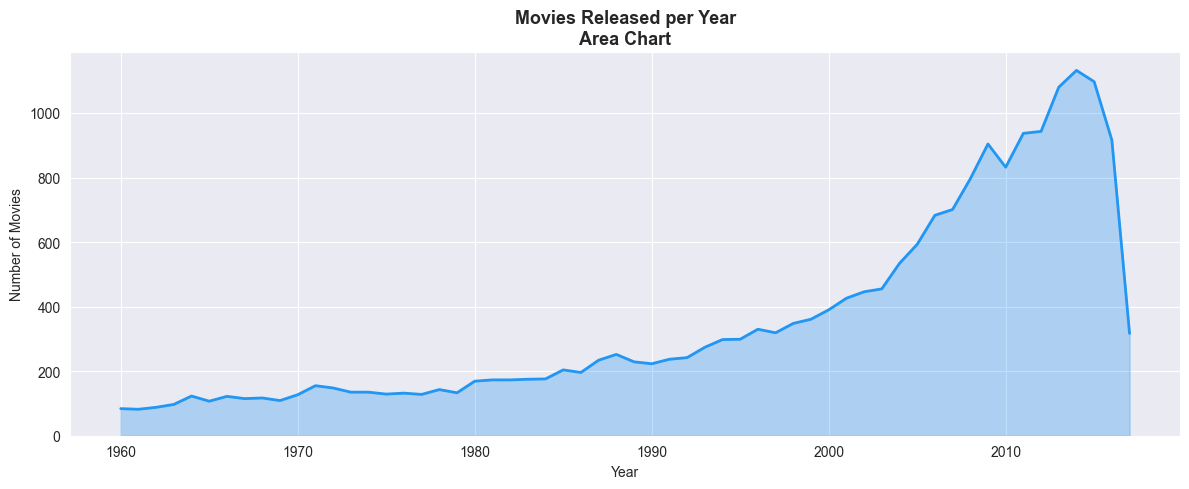

In [7]:
# Matplotlib Area Chart

plt.figure(figsize=(12,5))

plt.plot(
    movies_per_year['year'],
    movies_per_year['count'],
    color=BLUE,
    linewidth=2
)

plt.fill_between(
    movies_per_year['year'],
    movies_per_year['count'],
    color=BLUE,
    alpha=0.3
)

plt.ylim(0, None)  # IMPORTANT: enforce zero baseline

plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Movies Released per Year\nArea Chart',
          fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

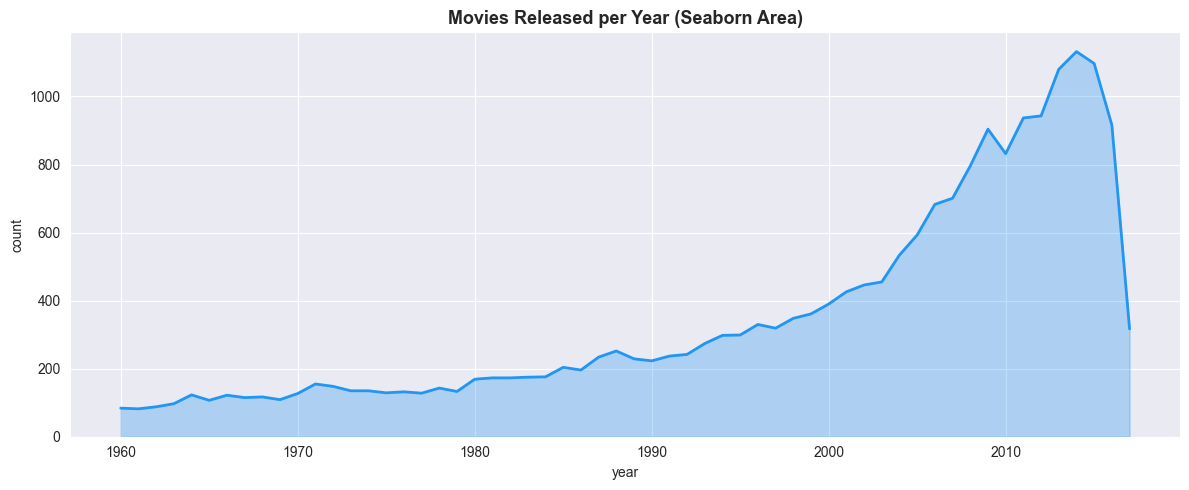

In [8]:
# Seaborn

plt.figure(figsize=(12,5))

sns.lineplot(
    data=movies_per_year,
    x='year',
    y='count',
    color=BLUE,
    linewidth=2
)

plt.fill_between(
    movies_per_year['year'],
    movies_per_year['count'],
    color=BLUE,
    alpha=0.3
)

plt.ylim(0, None)

plt.title('Movies Released per Year (Seaborn Area)',
          fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
# Plotly Area Chart

fig = px.area(
    movies_per_year,
    x='year',
    y='count',
    title='Movies Released per Year<br><sup>Area Chart</sup>'
)

fig.show()

### Insight

- Growth becomes **visually stronger** than in a line chart
- The shaded region highlights **scale and accumulation**
- Especially useful for presentations and storytelling

## Part 3 — When NOT to Use Area Charts

Area charts are powerful — but easy to misuse.

---

### ❌ Bad Use Cases

1. Comparing multiple unrelated series  
2. When exact values matter more than volume  
3. When baseline is not zero  
4. Too many overlapping areas  

---

### Example Problem

If you overlay multiple filled areas:
- They **hide each other**
- The chart becomes unreadable

👉 Solution: use **stacked area chart**

## Scenario 2 — Stacked Area Chart

### Question:
How do different categories contribute to a total over time?

---

### Example:
Movies vs TV Shows (Netflix dataset)

---

### Why Stacked Area?

- Shows **total + composition**
- Each layer represents a category

---
## Dataset 2 — Netflix Titles


In [10]:
dfn = pd.read_csv('data/netflix_titles.csv')
dfn.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
dfn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [12]:
dfn['date_added']   = pd.to_datetime(dfn['date_added'].str.strip(), errors='coerce')
dfn['year_added']   = dfn['date_added'].dt.year
dfn['duration_min'] = pd.to_numeric(
    dfn['duration'].str.replace(' min', '', regex=False),
    errors='coerce'
)

titles_per_year = (
    dfn.dropna(subset=['year_added'])
    .groupby(['year_added', 'type'])
    .size()
    .reset_index(name='count')
)
titles_per_year = titles_per_year[titles_per_year['year_added'] >= 2010].copy()

movies_n = dfn[
    (dfn['type'] == 'Movie') &
    (dfn['duration_min'] >= 30) &
    (dfn['duration_min'] <= 300) &
    (dfn['release_year'] >= 1980) &
    (dfn['release_year'] <= 2021)
].copy()

print(f'Title-year rows: {len(titles_per_year)}')
print(f'Movies for duration trend: {len(movies_n):,}')

Title-year rows: 21
Movies for duration trend: 5,892


In [15]:
titles_per_year.head()

,year_added,type,count
3,2010.0,Movie,1
4,2011.0,Movie,13
5,2012.0,Movie,3
6,2013.0,Movie,6
7,2013.0,TV Show,5


In [13]:
pivot = titles_per_year.pivot(
    index='year_added',
    columns='type',
    values='count'
).fillna(0)

pivot.head()

type,Movie,TV Show
year_added,,
2010.0,1.0,0.0
2011.0,13.0,0.0
2012.0,3.0,0.0
2013.0,6.0,5.0
2014.0,19.0,5.0


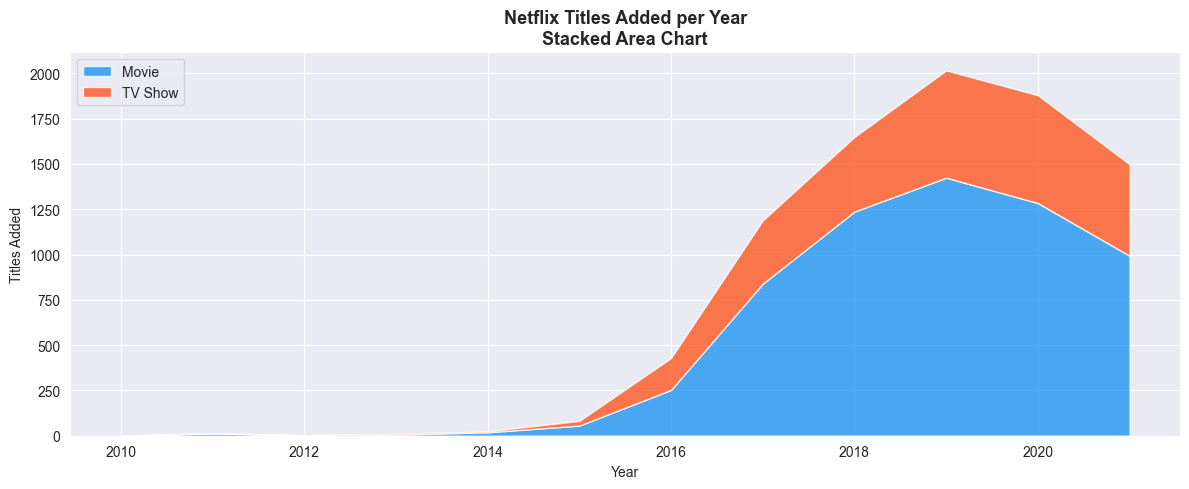

In [14]:
# Matplotlib Stacked Area

plt.figure(figsize=(12,5))

plt.stackplot(
    pivot.index,
    pivot['Movie'],
    pivot['TV Show'],
    labels=['Movie', 'TV Show'],
    colors=[BLUE, ORANGE],
    alpha=0.8
)

plt.legend(loc='upper left')
plt.ylim(0, None)

plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.title('Netflix Titles Added per Year\nStacked Area Chart',
          fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# Plotly Stacked Area

fig = px.area(
    titles_per_year,
    x='year_added',
    y='count',
    color='type',
    title='Netflix Titles Added per Year<br><sup>Stacked Area Chart</sup>'
)

fig.show()

### Insight

- Total height = total titles
- Each color = contribution of a category
- Great for showing **composition over time**

## Part 4 — Area Chart vs Line Chart

| Feature | Line Chart | Area Chart |
|--------|------------|------------|
| Focus | Trend | Trend + Volume |
| Visual weight | Light | Heavy |
| Requires y=0 | No | Yes |
| Best for | Analysis | Storytelling |

---

### Rule of Thumb

- Want **trend clarity** → Line chart  
- Want **impact + magnitude** → Area chart  

## Part 5 — Design Guidelines

### ✅ Best Practices

- Always start y-axis at **zero**
- Use **light transparency (alpha)**
- Avoid too many stacked categories (max 3–5)
- Keep colors soft and distinguishable

---

### ❌ Common Mistakes

- Starting y-axis above zero ❌
- Using area for precise comparisons ❌
- Overlapping too many series ❌

## Part 6 — Decision Guide

```
Single time series?
        |
   Do you care about volume?
        /        \
      Yes        No
      |           |
  Area Chart   Line Chart

Multiple series?
        |
   Want composition?
        /        \
      Yes        No
      |           |
Stacked Area   Multi-line
```

## Practice

### Exercise 1

**Question:**  
How has total revenue of movies changed over time?

---

### Tasks:

1. Group by year → sum revenue  
2. Plot an **area chart**  
3. Ensure y-axis starts at 0  
4. Compare with line chart  

---